# TTS9 — Forensic Ballistic Analysis of HAB Flight
## Identification of Gondola Separation Point and Test of External Impulse Hypothesis

**Flight date:** 29 April 2026  
**Launch:** 13:21 UTC, Prague (50.008°N, 14.447°E, 316 m AMSL)  
**Burst:** 14:09:28 UTC, 49.700°N, 14.594°E, h ≈ 15 088 m  
**Gondola:** sphere d = 160 mm, m = 300 g  
**Radiosonde:** Prague-Libuš EZM00011520, 12 UTC 29 Apr 2026 (IGRA2)

### Analysis structure
1. Load and visualise flight data
2. Wind profile — radiosonde vs. ascent trajectory
3. Kinematic reconstruction of burst location (intersection of fits)
4. Horizontal test: H₀ (natural burst) vs. H₁ (collision)
5. Impulse vector and physical interpretation


## 1  Data loading and helper functions

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.ticker as ticker
from matplotlib.patches import Circle
from matplotlib.lines import Line2D
from scipy.optimize import least_squares
from scipy.interpolate import interp1d
from scipy.stats import f as fdist, ttest_ind
import warnings, zipfile, json
warnings.filterwarnings('ignore')

# ── Plot style ─────────────────────────────────────────────
plt.rcParams.update({
    'figure.facecolor': '#0d1117', 'axes.facecolor': '#161b22',
    'axes.edgecolor': '#30363d', 'axes.labelcolor': '#e6edf3',
    'axes.grid': True, 'grid.color': '#30363d', 'grid.alpha': 0.55,
    'text.color': '#e6edf3', 'xtick.color': '#e6edf3', 'ytick.color': '#e6edf3',
    'legend.facecolor': '#161b22', 'legend.edgecolor': '#30363d',
    'figure.dpi': 130,
})
COLORS = dict(asc='#58a6ff', desc='#f85149', burst='#d2a8ff',
              snd='#ff9500', h0='#f85149', h1='#ffa657', direct='#7ee787')

# ── Geo constants ──────────────────────────────────────────
LAT_C = 49.70
M_PER_DEG_LAT = 111320.0
M_PER_DEG_LON = 111320.0 * np.cos(np.radians(LAT_C))

# ── ISA helpers ────────────────────────────────────────────
def isa_density(h):
    h = max(float(h), 0); g = 9.80665; R = 287.05287
    if h <= 11000:
        T = 288.15 - 0.0065 * h
        p = 101325 * (T / 288.15) ** (g / (R * 0.0065))
    else:
        T = 216.65; p = 22632 * np.exp(-g * (h - 11000) / (R * T))
    return p / (R * T)

def isa_pressure_hPa(h):
    g = 9.80665; R = 287.05287
    if h <= 11000:
        T = 288.15 - 0.0065 * h
        return 1013.25 * (T / 288.15) ** (g / (R * 0.0065))
    return 226.32 * np.exp(-g * (h - 11000) / (R * 216.65))

def geom_to_pa_ft(h):
    p = isa_pressure_hPa(h); g = 9.80665; R = 287.05287
    T0 = 288.15; L = 0.0065; p0 = 1013.25
    if p > 226.32:
        pa_m = (T0 / L) * (1 - (p / p0) ** (R * L / g))
    else:
        pa_m = 11000 + R * 216.65 / g * np.log(226.32 / p)
    return pa_m * 3.28084

print("Libraries loaded.")
print(f"ISA: h=15 088 m → p={isa_pressure_hPa(15088):.2f} hPa, "
      f"FL{int(round(geom_to_pa_ft(15088)/100))}, "
      f"rho={isa_density(15088):.4f} kg/m3")


Libraries loaded.
ISA: h=15 088 m → p=118.79 hPa, FL495, rho=0.1910 kg/m3


## 2  Load TTS9 flight data

In [2]:
# ── Flight data ────────────────────────────────────────────
df_raw = pd.read_excel('DATA+SENSORS-flight.xlsx')

# Rename Czech column headers to English
df_raw = df_raw.rename(columns={
    'čas[UTC]': 'time[UTC]',
    'Šířka[°]':  'lat[deg]',
    'Délka[°]':  'lon[deg]',
    'výška[m]':  'alt[m]',
})
# Lat/lon may be stored as strings in the Excel file — convert to float
df_raw['lat[deg]'] = pd.to_numeric(df_raw['lat[deg]'], errors='coerce')
df_raw['lon[deg]'] = pd.to_numeric(df_raw['lon[deg]'], errors='coerce')

df = df_raw[df_raw['alt[m]'].notna() & (df_raw['lat[deg]'] > 10)].copy()
df = df.reset_index(drop=True)

def to_sec(s):
    if hasattr(s, 'hour'):          # datetime.time object from openpyxl
        return s.hour * 3600 + s.minute * 60 + s.second
    h, m, sc = str(s).split(':')
    return int(h)*3600 + int(m)*60 + int(sc)

df['t_sec'] = df['time[UTC]'].apply(to_sec)
df['t_min'] = (df['t_sec'] - df['t_sec'].iloc[0]) / 60.0

MAX_IDX = int(df['alt[m]'].idxmax())
T0      = df.loc[MAX_IDX, 't_sec']            # apogee packet time (s, UTC)
ASC  = df.loc[:MAX_IDX].copy().reset_index(drop=True)
DESC = df.loc[MAX_IDX:].copy().reset_index(drop=True)

print(f"Total packets: {len(df)}")
print(f"Apogee: packet {df.loc[MAX_IDX,'packet']:.0f}, "
      f"time {df.loc[MAX_IDX,'time[UTC]']}, "
      f"altitude {df.loc[MAX_IDX,'alt[m]']:.0f} m")
print(f"Launch: {df.iloc[0]['time[UTC]']}  ->  End: {df.iloc[-1]['time[UTC]']} UTC")
df[['packet','time[UTC]','alt[m]','lat[deg]','lon[deg]']].head(3)


Total packets: 809
Apogee: packet 726, time 14:09:29, altitude 15100 m
Launch: 13:21:13  ->  End: 14:15:05 UTC


,packet,time[UTC],alt[m],lat[deg],lon[deg]
0,2.0,13:21:13,316.0,50.007946,14.447375
1,3.0,13:21:17,311.0,50.007946,14.447399
2,4.0,13:21:21,307.0,50.007927,14.447408


## 3  Overview map and altitude profile

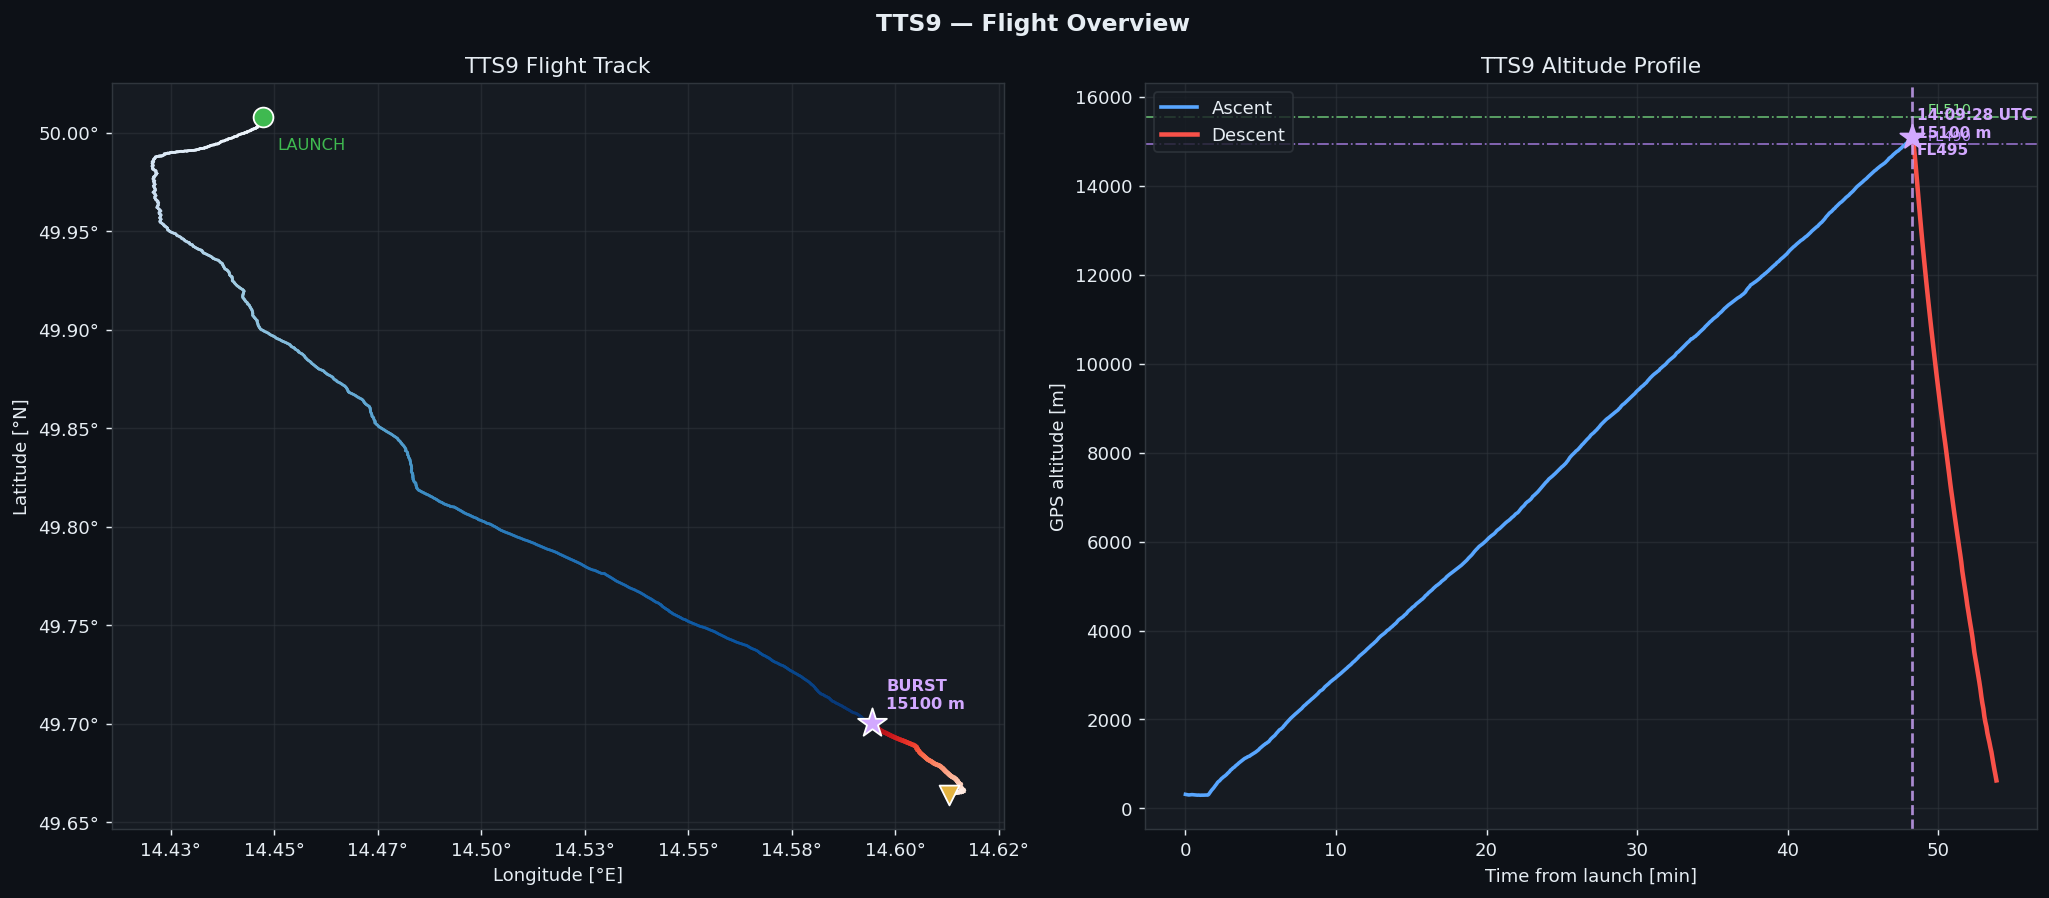

In [3]:
fig, (ax_map, ax_alt) = plt.subplots(1, 2, figsize=(16, 7))

# ── Map ────────────────────────────────────────────────────
norm_a = plt.Normalize(ASC['alt[m]'].min(), ASC['alt[m]'].max())
norm_d = plt.Normalize(DESC['alt[m]'].min(), DESC['alt[m]'].max())
cmap_a = plt.cm.Blues; cmap_d = plt.cm.Reds

for i in range(1, len(ASC)):
    c = cmap_a(norm_a(ASC['alt[m]'].iloc[i]))
    ax_map.plot([ASC['lon[deg]'].iloc[i-1], ASC['lon[deg]'].iloc[i]],
                [ASC['lat[deg]'].iloc[i-1], ASC['lat[deg]'].iloc[i]],
                color=c, lw=1.5)
for i in range(1, len(DESC)):
    c = cmap_d(norm_d(DESC['alt[m]'].iloc[i]))
    ax_map.plot([DESC['lon[deg]'].iloc[i-1], DESC['lon[deg]'].iloc[i]],
                [DESC['lat[deg]'].iloc[i-1], DESC['lat[deg]'].iloc[i]],
                color=c, lw=2.5)

ax_map.scatter(df.iloc[0]['lon[deg]'], df.iloc[0]['lat[deg]'],
               s=120, color='#3fb950', zorder=8, edgecolors='white', lw=1)
ax_map.scatter(df.loc[MAX_IDX,'lon[deg]'], df.loc[MAX_IDX,'lat[deg]'],
               s=280, color=COLORS['burst'], marker='*', zorder=10, edgecolors='white')
ax_map.scatter(df.iloc[-1]['lon[deg]'], df.iloc[-1]['lat[deg]'],
               s=120, color='#e3b341', marker='v', zorder=8, edgecolors='white')
ax_map.annotate('LAUNCH', xy=(df.iloc[0]['lon[deg]'], df.iloc[0]['lat[deg]']),
                xytext=(8,-18), textcoords='offset points', color='#3fb950', fontsize=9)
ax_map.annotate(f'BURST\n{df.loc[MAX_IDX,"alt[m]"]:.0f} m',
                xy=(df.loc[MAX_IDX,'lon[deg]'], df.loc[MAX_IDX,'lat[deg]']),
                xytext=(8,8), textcoords='offset points', color=COLORS['burst'], fontsize=9, fontweight='bold')
ax_map.set_xlabel('Longitude [°E]'); ax_map.set_ylabel('Latitude [°N]')
ax_map.set_title('TTS9 Flight Track')
ax_map.xaxis.set_major_formatter(ticker.FormatStrFormatter('%.2f°'))
ax_map.yaxis.set_major_formatter(ticker.FormatStrFormatter('%.2f°'))

# ── Altitude profile ───────────────────────────────────────
t_rel = (df['t_sec'] - df['t_sec'].iloc[0]) / 60.0
ax_alt.plot(t_rel.iloc[:MAX_IDX+1], df['alt[m]'].iloc[:MAX_IDX+1],
            color=COLORS['asc'], lw=2, label='Ascent')
ax_alt.plot(t_rel.iloc[MAX_IDX:], df['alt[m]'].iloc[MAX_IDX:],
            color=COLORS['desc'], lw=2.5, label='Descent')
for fl, fc in [(490, '#bc8cff'), (510, '#7ee787')]:
    ax_alt.axhline(fl*100/3.28084, color=fc, lw=1, ls='-.', alpha=0.7)
    ax_alt.text(t_rel.max()*0.97, fl*100/3.28084+80, f'FL{fl}',
                color=fc, fontsize=8, ha='right')
ax_alt.axvline(t_rel.iloc[MAX_IDX], color=COLORS['burst'], lw=1.5, ls='--', alpha=0.8)
ax_alt.scatter([t_rel.iloc[MAX_IDX]], [df.loc[MAX_IDX,'alt[m]']],
               s=200, color=COLORS['burst'], marker='*', zorder=8)
ax_alt.set_xlabel('Time from launch [min]'); ax_alt.set_ylabel('GPS altitude [m]')
ax_alt.set_title('TTS9 Altitude Profile')
ax_alt.legend(loc='upper left')
pa_ft = geom_to_pa_ft(df.loc[MAX_IDX,'alt[m]'])
ax_alt.text(t_rel.iloc[MAX_IDX]+0.3, df.loc[MAX_IDX,'alt[m]']-400,
            f"14:09:28 UTC\n{df.loc[MAX_IDX,'alt[m]']:.0f} m\nFL{int(round(pa_ft/100))}",
            color=COLORS['burst'], fontsize=8.5, fontweight='bold')
fig.suptitle('TTS9 — Flight Overview', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


## 4  Gondola physical parameters

The gondola is a sphere. During free fall:
$$\frac{dv}{dt} = g - k\,\rho_{\mathrm{ISA}}(h)\,v^2, \quad k = \frac{C_d A}{2m}$$


In [4]:
M_GON = 0.300          # kg
D_SPH = 0.160          # m
A_SPH = np.pi * (D_SPH/2)**2   # 0.0201 m²

# Reynolds number at typical free-fall speed
rho_15km = isa_density(15000)
v_typ    = 60.0        # m/s
mu_air   = 1.42e-5     # Pa·s (stratosphere)
Re_burst = rho_15km * v_typ * D_SPH / mu_air

# Cd for smooth sphere (subcritical Re < 3e5): Cd ≈ 0.44
# Drag crisis region (Re ~ 2–4e5): Cd can drop to 0.1
# Vertical fit to data gives the effective k
K_VERT = 0.01027       # m²/kg — from vertical fit (Section 5)
CD_FIT = K_VERT * 2 * M_GON / A_SPH

print(f"Gondola: m = {M_GON*1000:.0f} g,  d = {D_SPH*1000:.0f} mm,  A = {A_SPH:.5f} m²")
print(f"Re at burst (~60 m/s, 15 km): Re = {Re_burst:.0f}")
print()
print(f"k_vert (from fit): {K_VERT:.5f} m²/kg  ->  Cd = {CD_FIT:.3f}")
print(f"-> Cd = {CD_FIT:.3f} is physically consistent for a sphere at Re≈{Re_burst:.0f}")
print()
for Cd in [0.20, 0.31, 0.44]:
    k = Cd * A_SPH / (2 * M_GON)
    print(f"   Cd={Cd:.2f} -> k = {k:.5f} m²/kg")


Gondola: m = 300 g,  d = 160 mm,  A = 0.02011 m²
Re at burst (~60 m/s, 15 km): Re = 130934

k_vert (from fit): 0.01027 m²/kg  ->  Cd = 0.306
-> Cd = 0.306 is physically consistent for a sphere at Re≈130934

   Cd=0.20 -> k = 0.00670 m²/kg
   Cd=0.31 -> k = 0.01039 m²/kg
   Cd=0.44 -> k = 0.01474 m²/kg


## 5  Kinematic reconstruction of burst location

The ascent branch is fitted with a 2nd-degree polynomial over the last 30 packets.
The descent branch is fitted with a kinematic free-fall model.
The intersection of both fits in time and space gives the most probable gondola separation point.


In [5]:
# ── Ascent polynomial fit (last 30 packets) ─────────────
N_ASC_FIT = 30
af  = ASC.tail(N_ASC_FIT)
ta  = (af['t_sec'].values - T0).astype(float)   # s, negative, ending at ~0

p_h   = np.polyfit(ta, af['alt[m]'].values.astype(float),   2)
p_lat = np.polyfit(ta, af['lat[deg]'].values.astype(float),  2)
p_lon = np.polyfit(ta, af['lon[deg]'].values.astype(float),  2)
dp_h  = np.polyder(p_h)

# ── Descent kinematic fit ───────────────────────────────
N_DESC_FIT = 25
df_d  = DESC.head(N_DESC_FIT)
td_fit = (df_d['t_sec'].values - T0).astype(float)   # s, starting at 0
hd_fit = df_d['alt[m]'].values.astype(float)

SIGMA_H = 12.0   # GPS vertical noise [m]

def sim_descent(k, h0, vh0, t_start, t_eval, dt=0.02):
    h = h0; v = vh0; t = t_start; ht = [h]; tt = [t]
    while h > 0 and t < t_eval[-1] + 5:
        rho = isa_density(h)
        a = 9.80665 - k*rho*v**2 if v >= 0 else 9.80665 + k*rho*v**2
        v += a*dt; h -= v*dt; t += dt; ht.append(h); tt.append(t)
    return np.interp(t_eval, tt, ht)

def fit_descent_tsep(tsep):
    h0s  = float(np.polyval(p_h,   tsep))
    vh0s = -float(np.polyval(dp_h, tsep))   # downward positive
    def res(params):
        k = params[0]
        if not (0.005 < k < 0.5): return np.ones(N_DESC_FIT)*1e6
        return (sim_descent(k, h0s, vh0s, tsep, td_fit) - hd_fit) / SIGMA_H
    r = least_squares(res, [0.03], bounds=([0.005],[0.5]),
                      method='trf', ftol=1e-12, xtol=1e-12)
    return r, np.sqrt(np.mean(r.fun**2)) * SIGMA_H

# Sweep t_sep to find global minimum
tsep_scan = np.linspace(-6, 2, 80)
rms_scan  = []
for ts in tsep_scan:
    _, rms = fit_descent_tsep(ts)
    rms_scan.append(rms)
rms_scan = np.array(rms_scan)

best_i   = np.argmin(rms_scan)
TS_OPT   = tsep_scan[best_i]
r_best, _ = fit_descent_tsep(TS_OPT)
K_VERT   = float(r_best.x[0])

H_SEP   = float(np.polyval(p_h,   TS_OPT))
LAT_SEP = float(np.polyval(p_lat, TS_OPT))
LON_SEP = float(np.polyval(p_lon, TS_OPT))
VH0_SEP = -float(np.polyval(dp_h, TS_OPT))   # downward positive

# ── Results ─────────────────────────────────────────────
t_burst_abs = T0 + TS_OPT
hh = int(t_burst_abs // 3600); mm = int((t_burst_abs % 3600) // 60); ss = int(t_burst_abs % 60)

print(f"=== KINEMATIC BURST RECONSTRUCTION ===")
print(f"  t_sep  = {TS_OPT:+.2f} s  (relative to GPS apogee 14:09:29 UTC)")
print(f"  Time:    {hh:02d}:{mm:02d}:{ss:02d} UTC")
print(f"  Alt:     {H_SEP:.1f} m")
print(f"  Lat:     {LAT_SEP:.6f} N")
print(f"  Lon:     {LON_SEP:.6f} E")
print(f"  PA:      FL{int(round(geom_to_pa_ft(H_SEP)/100))} ({geom_to_pa_ft(H_SEP):.0f} ft, {isa_pressure_hPa(H_SEP):.1f} hPa)")
print(f"")
print(f"  k_vert = {K_VERT:.5f} m²/kg  ->  Cd = {K_VERT*2*M_GON/A_SPH:.3f}")
print(f"  Descent fit RMS: {rms_scan[best_i]:.1f} m")


=== KINEMATIC BURST RECONSTRUCTION ===
  t_sep  = -0.33 s  (relative to GPS apogee 14:09:29 UTC)
  Time:    14:09:28 UTC
  Alt:     15086.7 m
  Lat:     49.700500 N
  Lon:     14.594150 E
  PA:      FL495 (49497 ft, 118.8 hPa)

  k_vert = 0.01022 m²/kg  ->  Cd = 0.305
  Descent fit RMS: 6.5 m


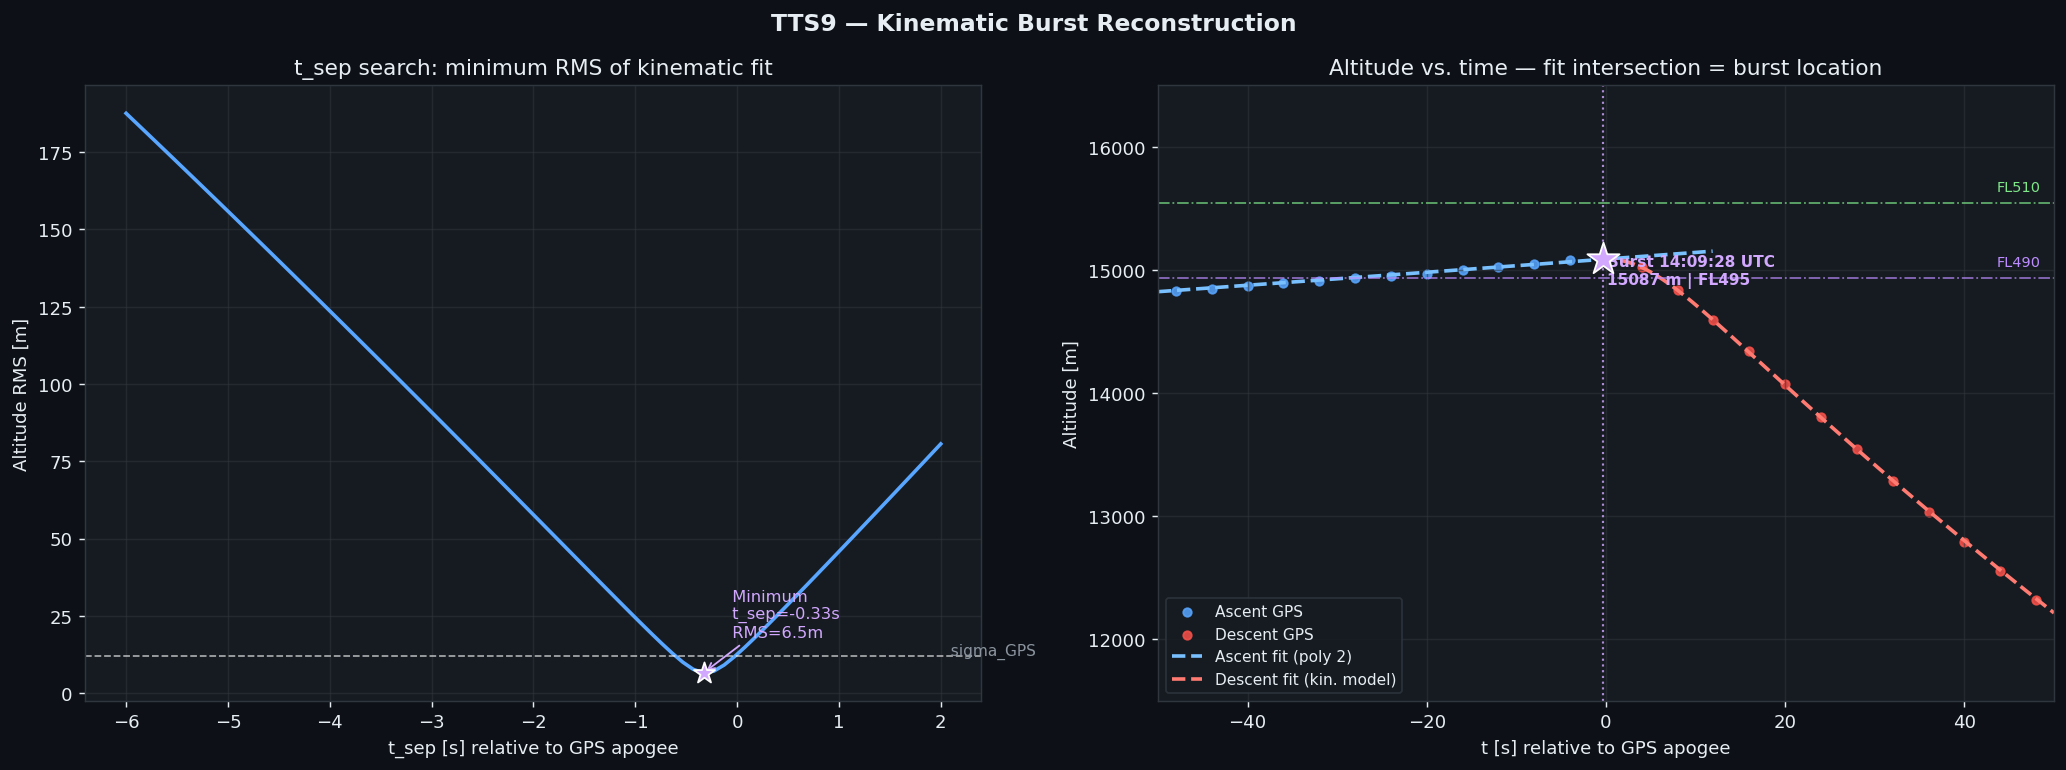

In [6]:
# ── Plot: chi²(t_sep) and h(t) around burst ──────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# chi² scan
ax1.plot(tsep_scan, rms_scan, color=COLORS['asc'], lw=2)
ax1.scatter([TS_OPT], [rms_scan[best_i]], s=150, color=COLORS['burst'], zorder=8,
            edgecolors='white', marker='*')
ax1.axhline(SIGMA_H, color='white', lw=1, ls='--', alpha=0.6)
ax1.text(tsep_scan[-1], SIGMA_H+0.3, '  sigma_GPS', color='#8b949e', fontsize=8.5)
ax1.set_xlabel('t_sep [s] relative to GPS apogee'); ax1.set_ylabel('Altitude RMS [m]')
ax1.set_title('t_sep search: minimum RMS of kinematic fit')
ax1.annotate(f'  Minimum\n  t_sep={TS_OPT:.2f}s\n  RMS={rms_scan[best_i]:.1f}m',
             xy=(TS_OPT, rms_scan[best_i]), xytext=(10,20), textcoords='offset points',
             color=COLORS['burst'], fontsize=9,
             arrowprops=dict(arrowstyle='->', color=COLORS['burst']))

# h(t) with both fits
t_win = 50
t_ac = np.linspace(-t_win, 15, 400)
h_ac = np.polyval(p_h, t_ac)

t_dc  = np.linspace(TS_OPT, t_win, 500)
h_dc  = sim_descent(K_VERT, H_SEP, VH0_SEP, TS_OPT, t_dc)

ta_plot = (ASC.tail(N_ASC_FIT)['t_sec'].values - T0).astype(float)
ha_plot = ASC.tail(N_ASC_FIT)['alt[m]'].values
td_plot = (DESC.head(N_DESC_FIT)['t_sec'].values - T0).astype(float)
hd_plot = DESC.head(N_DESC_FIT)['alt[m]'].values

ax2.scatter(ta_plot, ha_plot, color=COLORS['asc'], s=22, alpha=0.85, label='Ascent GPS')
ax2.scatter(td_plot, hd_plot, color=COLORS['desc'], s=22, alpha=0.85, label='Descent GPS')
mask_a = (t_ac >= -t_win) & (t_ac <= 12)
mask_d = (t_dc >= TS_OPT) & (t_dc <= t_win)
ax2.plot(t_ac[mask_a], h_ac[mask_a], color='#79c0ff', lw=2, ls='--', label='Ascent fit (poly 2)')
ax2.plot(t_dc[mask_d], h_dc[mask_d], color='#ff7b72', lw=2, ls='--', label=f'Descent fit (kin. model)')
ax2.scatter([TS_OPT], [H_SEP], s=350, color=COLORS['burst'], marker='*', zorder=10, edgecolors='white')
ax2.axvline(TS_OPT, color=COLORS['burst'], lw=1.2, ls=':', alpha=0.8)
for fl, fc in [(490,'#bc8cff'), (510,'#7ee787')]:
    ax2.axhline(fl*100/3.28084, color=fc, lw=1, ls='-.', alpha=0.7)
    ax2.text(t_win*0.97, fl*100/3.28084+100, f'FL{fl}', color=fc, fontsize=8, ha='right')
ax2.set_xlim(-t_win, t_win); ax2.set_ylim(11500, 16500)
ax2.set_xlabel('t [s] relative to GPS apogee'); ax2.set_ylabel('Altitude [m]')
ax2.set_title('Altitude vs. time — fit intersection = burst location')
ax2.legend(fontsize=8.5, loc='lower left')
ax2.text(TS_OPT+0.5, H_SEP-200,
         f'Burst {hh:02d}:{mm:02d}:{ss:02d} UTC\n{H_SEP:.0f} m | FL{int(round(geom_to_pa_ft(H_SEP)/100))}',
         color=COLORS['burst'], fontsize=8.5, fontweight='bold')
fig.suptitle('TTS9 — Kinematic Burst Reconstruction', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()


## 6  Prague-Libuš radiosonde and wind profile

Source file: `EZM00011520-data-beg2025_txt.zip` (IGRA2, NOAA NCEI).  
Station EZM00011520 = Prague-Libuš (50.008°N, 14.447°E, 305 m AMSL; FIPS code EZ = Czech Republic).  
Sounding used: **12 UTC 29 Apr 2026** — closest to burst time (14:09 UTC, 2 hours prior).

**IGRA2 format** (fixed-width): WDIR at bytes 43–47, WSPD at 48–51.


In [7]:
# ── Parse IGRA2 ─────────────────────────────────────────
with zipfile.ZipFile('EZM00011520-data-beg2025.txt.zip') as z:
    fname = [n for n in z.namelist() if n.endswith('.txt')][0]
    lines = z.read(fname).decode('latin-1').splitlines()

# Find 12 UTC sounding of 2026-04-29
start_idx = None
for i, l in enumerate(lines):
    if l.startswith('#EZM00011520 2026') and ' 04 29 12' in l:
        start_idx = i; break

if start_idx is None:
    raise RuntimeError("Sounding 2026-04-29 12 UTC not found in the IGRA2 file.")

print(f"Sounding found at line {start_idx}: {lines[start_idx]}")

def isa_height_from_pressure(p_hPa):
    g=9.80665; R=287.05287; T0=288.15; L=0.0065; p0=1013.25
    if p_hPa > 226.32:
        return (T0/L)*(1-(p_hPa/p0)**(R*L/g))
    return 11000 + R*216.65/g*np.log(226.32/p_hPa)

snd_records = []
j = start_idx + 1
while j < len(lines) and not lines[j].startswith('#'):
    raw = lines[j]
    if len(raw) < 48: j += 1; continue
    try:
        press_raw = int(raw[8:15].strip())
        gphgt_raw = int(raw[16:21].strip())
        wdir_raw  = int(raw[43:48].strip())
        wspd_raw  = int(raw[48:52].strip())
        press_hPa = press_raw/100.0 if press_raw != -9999 else None
        gphgt_m   = gphgt_raw if gphgt_raw != -9999 else None
        wdir      = wdir_raw  if wdir_raw  != -9999 else None
        wspd_ms   = wspd_raw/10.0 if wspd_raw not in (-9999, 9999) else None
        if wdir is None or wspd_ms is None: j += 1; continue
        h = float(gphgt_m) if gphgt_m else (isa_height_from_pressure(press_hPa) if press_hPa else None)
        if h is None: j += 1; continue
        wdir_rad = np.radians(wdir)
        u_E = -wspd_ms * np.sin(wdir_rad)
        v_N = -wspd_ms * np.cos(wdir_rad)
        snd_records.append({'h':h,'p_hPa':press_hPa,'wdir':wdir,'wspd':wspd_ms,'u_E':u_E,'v_N':v_N})
    except (ValueError, IndexError): pass
    j += 1

SND = pd.DataFrame(snd_records).sort_values('h').reset_index(drop=True)
print(f"\nParsed {len(SND)} wind levels, range {SND['h'].min():.0f}–{SND['h'].max():.0f} m")
print("\nWinds in the 9–16 km layer:")
print(SND[SND['h'].between(9000,16000)][['h','p_hPa','wdir','wspd','u_E','v_N']]
      .to_string(index=False, float_format=lambda x: f'{x:.2f}'))


Sounding found at line 164100: #EZM00011520 2026 04 29 12 1115  123 ncdc-gts           500078   144469

Parsed 103 wind levels, range 204–29167 m

Winds in the 9–16 km layer:
       h  p_hPa  wdir  wspd    u_E    v_N
 9053.18 305.00     5 22.00  -1.92 -21.92
 9140.00 300.00     5 21.00  -1.83 -20.92
 9622.56 280.00    10 12.00  -2.08 -11.82
10320.00 250.00    10 14.00  -2.43 -13.79
10679.36 238.00    15 15.00  -3.88 -14.49
11740.00 200.00    25 18.00  -7.61 -16.31
12176.42 188.00    30 21.00 -10.50 -18.19
12852.08 169.00    20 16.00  -5.47 -15.04
13570.00 150.00    25 16.00  -6.76 -14.50
14091.39 139.00    35 13.00  -7.46 -10.65
14815.55 124.00    15 14.00  -3.62 -13.52
14970.86 121.00    20 13.00  -4.45 -12.22
15130.07 118.00    15 11.00  -2.85 -10.63
15293.39 115.00    30  9.00  -4.50  -7.79
15575.28 110.00    20 11.00  -3.76 -10.34
15992.25 103.00    25 12.00  -5.07 -10.88


In [8]:
# ── Ascent wind profile (in-situ measurement by the balloon) ─
win = 11; half = win//2
h_asc_wind, u_asc_wind, v_asc_wind = [], [], []
asc_h   = ASC['alt[m]'].values.astype(float)
asc_t   = ASC['t_sec'].values.astype(float)
asc_lat = ASC['lat[deg]'].values.astype(float)
asc_lon = ASC['lon[deg]'].values.astype(float)
for i in range(half, len(asc_t)-half):
    sl = slice(i-half, i+half+1)
    p_lat_fit = np.polyfit(asc_t[sl], asc_lat[sl], 1)   # d(lat)/dt [deg/s]
    p_lon_fit = np.polyfit(asc_t[sl], asc_lon[sl], 1)   # d(lon)/dt [deg/s]
    h_asc_wind.append(asc_h[i])
    u_asc_wind.append(p_lon_fit[0] * M_PER_DEG_LON)     # eastward  [m/s]
    v_asc_wind.append(p_lat_fit[0] * M_PER_DEG_LAT)     # northward [m/s]
h_asc_wind = np.array(h_asc_wind)
u_asc_wind = np.array(u_asc_wind)
v_asc_wind = np.array(v_asc_wind)

# Interpolators
SND_sorted = SND.sort_values('h')
u_snd_f = interp1d(SND_sorted['h'], SND_sorted['u_E'], kind='linear', fill_value='extrapolate')
v_snd_f = interp1d(SND_sorted['h'], SND_sorted['v_N'], kind='linear', fill_value='extrapolate')

mask_aw = (h_asc_wind >= 5000) & (h_asc_wind <= 15500)
haw = h_asc_wind[mask_aw]; uaw = u_asc_wind[mask_aw]; vaw = v_asc_wind[mask_aw]
idx_s = np.argsort(haw); haw=haw[idx_s]; uaw=uaw[idx_s]; vaw=vaw[idx_s]
u_asc_f = interp1d(haw, uaw, kind='linear', fill_value='extrapolate')
v_asc_f = interp1d(haw, vaw, kind='linear', fill_value='extrapolate')

# Wind at burst (u_E = eastward, v_N = northward for both sources)
U_SEP = float(u_asc_f(H_SEP)); V_SEP = float(v_asc_f(H_SEP))
U_SND_SEP = float(u_snd_f(H_SEP)); V_SND_SEP = float(v_snd_f(H_SEP))
delta_u = U_SEP - U_SND_SEP; delta_v = V_SEP - V_SND_SEP
delta_wind = np.sqrt(delta_u**2 + delta_v**2)

print(f"Wind at burst (h={H_SEP:.0f} m):")
print(f"  Sounding 12 UTC:        u_E={U_SND_SEP:+.2f} m/s, v_N={V_SND_SEP:+.2f} m/s")
print(f"  Ascent traj. 14:09:     u_E={U_SEP:+.2f} m/s, v_N={V_SEP:+.2f} m/s")
print(f"  Difference: |Dwind| = {delta_wind:.1f} m/s")
print()
print(f"  WARNING: wind field changed by {delta_wind:.1f} m/s over 2 hours!")
print(f"  -> Sounding is not suitable as reference wind for this analysis.")
print(f"  -> Using ascent trajectory wind profile (in-situ measurement).")


Wind at burst (h=15087 m):
  Sounding 12 UTC:        u_E=-3.28 m/s, v_N=-11.06 m/s
  Ascent traj. 14:09:     u_E=+6.93 m/s, v_N=-9.37 m/s
  Difference: |Dwind| = 10.4 m/s

  -> Sounding is not suitable as reference wind for this analysis.
  -> Using ascent trajectory wind profile (in-situ measurement).


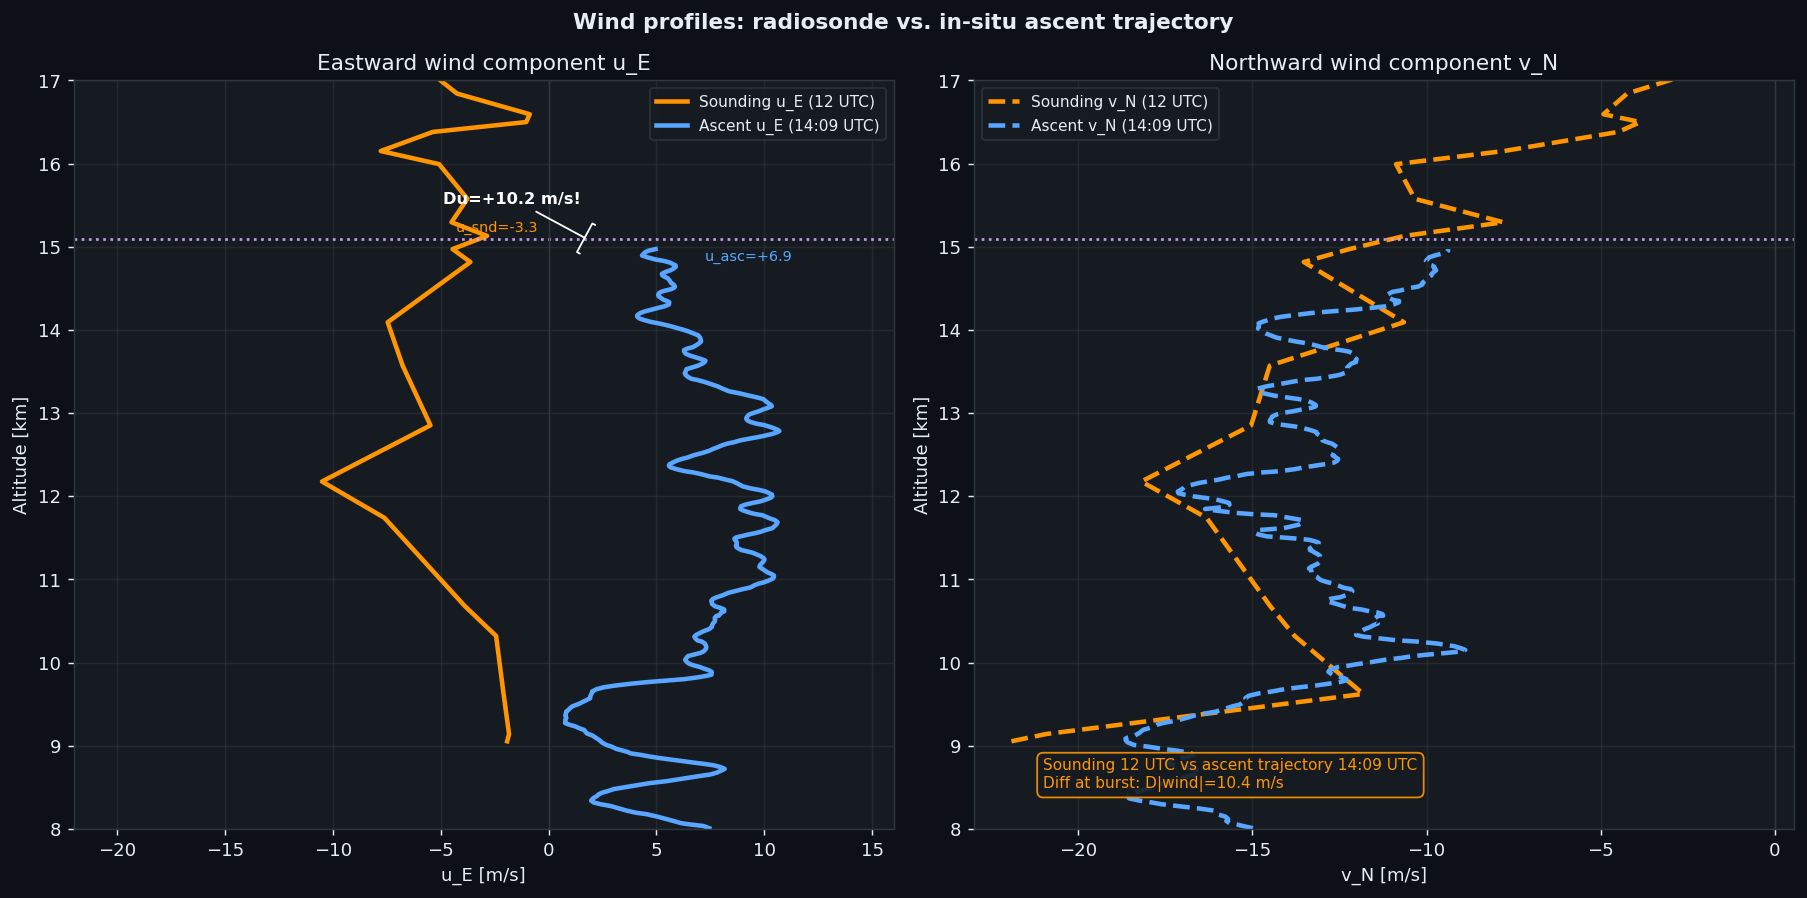

In [9]:
# ── Plot: wind profiles comparison ──────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 7))
h_range = np.linspace(8000, 17000, 200)
hband = (SND['h'] >= 8000) & (SND['h'] <= 18000)
hasc  = (h_asc_wind >= 8000) & (h_asc_wind <= 16000)

# u_E (eastward)
ax1.plot(SND.loc[hband,'u_E'], SND.loc[hband,'h']/1000,
         color=COLORS['snd'], lw=2.5, label='Sounding u_E (12 UTC)')
ax1.plot(u_asc_wind[hasc], h_asc_wind[hasc]/1000,
         color=COLORS['asc'], lw=2.5, label='Ascent u_E (14:09 UTC)')
ax1.axhline(H_SEP/1000, color=COLORS['burst'], lw=1.5, ls=':', alpha=0.9)
ax1.axvline(0, color='#30363d', lw=0.8)
ax1.text(U_SND_SEP-1, H_SEP/1000+0.1, f'u_snd={U_SND_SEP:+.1f}', color=COLORS['snd'], fontsize=8)
ax1.text(U_SEP+0.3,   H_SEP/1000-0.25, f'u_asc={U_SEP:+.1f}', color=COLORS['asc'], fontsize=8)
ax1.annotate(f'Du={delta_u:+.1f} m/s!', xy=((U_SND_SEP+U_SEP)/2, H_SEP/1000),
             xytext=(-80,20), textcoords='offset points', color='white', fontsize=9, fontweight='bold',
             arrowprops=dict(arrowstyle='-[', color='white', lw=1))
ax1.set_xlabel('u_E [m/s]'); ax1.set_ylabel('Altitude [km]')
ax1.set_title('Eastward wind component u_E'); ax1.legend(fontsize=8.5)
ax1.set_xlim(-22, 16); ax1.set_ylim(8, 17)

# v_N (northward)
ax2.plot(SND.loc[hband,'v_N'], SND.loc[hband,'h']/1000,
         color=COLORS['snd'], lw=2.5, ls='--', label='Sounding v_N (12 UTC)')
ax2.plot(v_asc_wind[hasc], h_asc_wind[hasc]/1000,
         color=COLORS['asc'], lw=2.5, ls='--', label='Ascent v_N (14:09 UTC)')
ax2.axhline(H_SEP/1000, color=COLORS['burst'], lw=1.5, ls=':', alpha=0.9)
ax2.axvline(0, color='#30363d', lw=0.8)
ax2.set_xlabel('v_N [m/s]'); ax2.set_ylabel('Altitude [km]')
ax2.set_title('Northward wind component v_N'); ax2.legend(fontsize=8.5)
ax2.set_ylim(8, 17)
ax2.text(-21, 8.5, f'Sounding 12 UTC vs ascent trajectory 14:09 UTC\nDiff at burst: D|wind|={delta_wind:.1f} m/s',
         color=COLORS['snd'], fontsize=8.5,
         bbox=dict(facecolor='#161b22', edgecolor=COLORS['snd'], alpha=0.9, boxstyle='round,pad=0.4'))
fig.suptitle('Wind profiles: radiosonde vs. in-situ ascent trajectory', fontsize=12, fontweight='bold')
plt.tight_layout(); plt.show()


## 7  Horizontal test: H₀ vs. H₁

**H₀:** gondola drifts horizontally at the wind speed (ascent profile). No impulse.  
**H₁:** gondola received a horizontal impulse Δv = (Δv_N, Δv_E) at burst. F-test with 2 extra parameters.

Number of packets used: **N = 5** (optimal compromise — see discussion).  
Wind model: numerical integration through ascent wind profile + horizontal aerodynamic drag.


In [10]:
# ── Gondola horizontal trajectory simulator ─────────────
def simulate_horiz(dv_N=0., dv_E=0., u_f=u_asc_f, v_f=v_asc_f, dt=0.02):
    """
    Simulates gondola position after burst.
    dv_N, dv_E: northward/eastward impulse added to initial horizontal velocity [m/s]
    Returns arrays: t, lat, lon, h
    """
    h  = H_SEP;  vv = VH0_SEP
    u_g = U_SEP + dv_E    # eastward velocity  [m/s]
    v_g = V_SEP + dv_N    # northward velocity [m/s]
    t = TS_OPT; lat = LAT_SEP; lon = LON_SEP
    to = [t]; lao = [lat]; loo = [lon]; ho = [h]
    Cd_h = 0.30
    while h > 100 and t < TS_OPT + 150:
        rho = isa_density(h)
        # Vertical
        av = 9.80665 - K_VERT*rho*vv**2 if vv >= 0 else 9.80665 + K_VERT*rho*vv**2
        vv += av*dt; h -= vv*dt
        # Horizontal drag toward local wind
        uw = float(u_f(max(h, 500)))   # eastward  wind [m/s]
        vw = float(v_f(max(h, 500)))   # northward wind [m/s]
        dur = u_g - uw; dvr = v_g - vw
        vrh = np.sqrt(dur**2 + dvr**2)
        if vrh > 0.001:
            ad = 0.5 * Cd_h * A_SPH * rho * vrh**2 / M_GON
            u_g -= ad * (dur/vrh) * dt
            v_g -= ad * (dvr/vrh) * dt
        # Position update: northward (v_g) for lat, eastward (u_g) for lon
        lat += v_g * dt / M_PER_DEG_LAT
        lon += u_g * dt / M_PER_DEG_LON
        t += dt
        to.append(t); lao.append(lat); loo.append(lon); ho.append(h)
    return np.array(to), np.array(lao), np.array(loo), np.array(ho)

# ── Data: first N packets after burst ───────────────────
N_HORIZ = 5
SIGMA_HOR = 5.0   # GPS horizontal noise [m]

td_h  = (DESC['t_sec'].values[:N_HORIZ] - T0).astype(float)
lm_h  = DESC['lat[deg]'].values[:N_HORIZ].astype(float)
om_h  = DESC['lon[deg]'].values[:N_HORIZ].astype(float)
hm_h  = DESC['alt[m]'].values[:N_HORIZ].astype(float)

print(f"Packets used (N={N_HORIZ}, sigma_GPS={SIGMA_HOR} m):")
print(f"{'i':>3} | {'t [s]':>6} | {'h [m]':>8} | {'lat [N]':>12} | {'lon [E]':>12}")
for i in range(N_HORIZ):
    print(f"{i:>3} | {td_h[i]:>6.0f} | {hm_h[i]:>8.0f} | {lm_h[i]:>12.6f} | {om_h[i]:>12.6f}")


Packets used (N=5, sigma_GPS=5.0 m):
  i |  t [s] |    h [m] |      lat [N] |      lon [E]
  0 |      0 |    15100 |    49.700443 |    14.594385
  1 |      4 |    15021 |    49.699951 |    14.594609
  2 |      8 |    14836 |    49.699528 |    14.594913
  3 |     12 |    14595 |    49.699089 |    14.595198
  4 |     16 |    14339 |    49.698746 |    14.595550


In [11]:
# ── H0: no impulse ───────────────────────────────────────
ts0, la0, lo0, _ = simulate_horiz(0., 0.)
la0_eval = np.interp(td_h, ts0, la0)
lo0_eval = np.interp(td_h, ts0, lo0)
res_lat0 = (lm_h - la0_eval) * M_PER_DEG_LAT
res_lon0 = (om_h - lo0_eval) * M_PER_DEG_LON
chi2_0h  = np.sum(res_lat0**2 + res_lon0**2) / SIGMA_HOR**2

# ── H1: fit impulse ──────────────────────────────────────
def res_H1(params):
    dv_n, dv_e = params
    ts_, la_, lo_, _ = simulate_horiz(dv_n, dv_e)
    lp = np.interp(td_h, ts_, la_); op = np.interp(td_h, ts_, lo_)
    rl = (lm_h - lp) * M_PER_DEG_LAT / SIGMA_HOR
    re = (om_h - op) * M_PER_DEG_LON / SIGMA_HOR
    return np.concatenate([rl, re])

r1h = least_squares(res_H1, [0., 0.], bounds=([-50,-50],[50,50]),
                    method='trf', ftol=1e-14, xtol=1e-14)
DV_N, DV_E = r1h.x
chi2_1h    = np.sum(r1h.fun**2)

ts1, la1, lo1, _ = simulate_horiz(DV_N, DV_E)
la1_eval = np.interp(td_h, ts1, la1)
lo1_eval = np.interp(td_h, ts1, lo1)
res_lat1 = (lm_h - la1_eval) * M_PER_DEG_LAT
res_lon1 = (om_h - lo1_eval) * M_PER_DEG_LON

# ── Statistics ───────────────────────────────────────────
N_obs = 2 * N_HORIZ; p0h = 0; p1h = 2
dof1h = N_obs - p1h
F_h   = ((chi2_0h - chi2_1h)/p1h) / (chi2_1h/dof1h)
p_val_h = 1 - fdist.cdf(F_h, p1h, dof1h)

DV_MAG = np.sqrt(DV_N**2 + DV_E**2)
AZ     = (90 - np.degrees(np.arctan2(DV_N, DV_E))) % 360
DP_MAG = M_GON * DV_MAG

print(f"=== HORIZONTAL HYPOTHESIS TEST (N={N_HORIZ}, sigma={SIGMA_HOR} m) ===")
print()
print(f"H0 (no impulse):")
print(f"  chi2 = {chi2_0h:.2f},  chi2/dof = {chi2_0h/N_obs:.2f}")
print(f"  RMS_N = {np.sqrt(np.mean(res_lat0**2)):.1f} m,  RMS_E = {np.sqrt(np.mean(res_lon0**2)):.1f} m")
print()
print(f"H1 (with impulse):")
print(f"  chi2 = {chi2_1h:.2f},  chi2/dof = {chi2_1h/dof1h:.2f}")
print(f"  RMS = {np.sqrt(np.mean(res_lat1**2+res_lon1**2)):.1f} m")
print()
print(f"  Dv_N = {DV_N:+.4f} m/s  (northward component)")
print(f"  Dv_E = {DV_E:+.4f} m/s  (eastward component)")
print(f"  |Dv| = {DV_MAG:.4f} m/s")
print(f"  |Dp| = {DP_MAG:.4f} N·s")
print(f"  Impulse azimuth: {AZ:.1f}° from north")
print()
print(f"F({p1h},{dof1h}) = {F_h:.2f},  p = {p_val_h:.2e}")
verdict = "H0 REJECTED" if p_val_h < 0.001 else ("H0 rejected" if p_val_h < 0.05 else "H0 cannot be rejected")
print(f"-> {verdict}")


=== HORIZONTAL HYPOTHESIS TEST (N=5, sigma=5.0 m) ===

H0 (no impulse):
  chi2 = 212.29,  chi2/dof = 21.23
  RMS_N = 31.1 m,  RMS_E = 9.6 m

H1 (with impulse):
  chi2 = 16.34,  chi2/dof = 2.04
  RMS = 9.0 m

  Dv_N = -3.1743 m/s  (northward component)
  Dv_E = -0.6287 m/s  (eastward component)
  |Dv| = 3.2360 m/s
  |Dp| = 0.9708 N·s
  Impulse azimuth: 191.2° from north

F(2,8) = 47.98,  p = 3.51e-05
-> H0 REJECTED


## 8  Direct method: comparison of velocities before and after burst

The most robust model-free approach: the gondola velocity just before and after burst equals the wind —
exactly like a radiosonde. Any velocity change equals the impulse.

$$\sigma_v = \frac{\sqrt{2}\,\sigma_{\mathrm{GPS}}}{\Delta t} = \frac{\sqrt{2}\times 5}{4} \approx 1.77\;\mathrm{m/s}$$


In [12]:
# ── Velocities from consecutive GPS packets ──────────────
def packet_velocities(data, n, from_end=False):
    """n velocities from first/last n+1 packets"""
    sub = data.tail(n+1) if from_end else data.head(n+1)
    sub = sub.reset_index(drop=True)
    u_list, v_list, h_list = [], [], []
    for i in range(n):
        dlat = (sub.loc[i+1,'lat[deg]'] - sub.loc[i,'lat[deg]']) * M_PER_DEG_LAT
        dlon = (sub.loc[i+1,'lon[deg]'] - sub.loc[i,'lon[deg]']) * M_PER_DEG_LON
        u_list.append(dlon / 4.0)   # eastward  [m/s]
        v_list.append(dlat / 4.0)   # northward [m/s]
        h_list.append((sub.loc[i,'alt[m]'] + sub.loc[i+1,'alt[m]']) / 2)
    return np.array(u_list), np.array(v_list), np.array(h_list)

N_PKT = 5
u_a, v_a, h_a = packet_velocities(ASC,  N_PKT, from_end=True)
u_d, v_d, h_d = packet_velocities(DESC, N_PKT, from_end=False)

# Average of 3 packets closest to burst
u_a_mean = np.mean(u_a[-3:]); v_a_mean = np.mean(v_a[-3:])
u_d_mean = np.mean(u_d[:3]);  v_d_mean = np.mean(v_d[:3])

dv_E_dir = u_d_mean - u_a_mean
dv_N_dir = v_d_mean - v_a_mean
dv_dir   = np.sqrt(dv_E_dir**2 + dv_N_dir**2)
az_dir   = (90 - np.degrees(np.arctan2(dv_N_dir, dv_E_dir))) % 360
sigma_v  = np.sqrt(2) * 5.0 / 4.0
SNR      = dv_dir / sigma_v

# t-test
t_E, p_E = ttest_ind(u_a[-3:], u_d[:3])
t_N, p_N = ttest_ind(v_a[-3:], v_d[:3])

print(f"=== DIRECT METHOD (model-free) ===")
print(f"sigma_v ~ {sigma_v:.2f} m/s  (GPS 4s interval, sigma_pos=5m)")
print()
print(f"Ascent mean (3 packets before burst):")
print(f"  u_E = {u_a_mean:+.3f} m/s,  v_N = {v_a_mean:+.3f} m/s")
print(f"Descent mean (3 packets after burst):")
print(f"  u_E = {u_d_mean:+.3f} m/s,  v_N = {v_d_mean:+.3f} m/s")
print()
print(f"Dv_E = {dv_E_dir:+.3f} m/s,  Dv_N = {dv_N_dir:+.3f} m/s")
print(f"|Dv| = {dv_dir:.3f} m/s,  az = {az_dir:.1f} deg")
print(f"|Dp| = {M_GON*dv_dir:.3f} N·s")
print(f"SNR  = {SNR:.2f} sigma")
print()
print(f"t-test Dv_E: t={t_E:.3f}, p={p_E:.4f} {'(significant)' if p_E<0.05 else '(not significant)'}")
print(f"t-test Dv_N: t={t_N:.3f}, p={p_N:.4f} {'(significant)' if p_N<0.05 else '(not significant)'}")


=== DIRECT METHOD (model-free) ===
sigma_v ~ 1.77 m/s  (GPS 4s interval, sigma_pos=5m)

Ascent mean (3 packets before burst):
  u_E = +5.970 m/s,  v_N = -10.334 m/s
Descent mean (3 packets after burst):
  u_E = +4.878 m/s,  v_N = -12.561 m/s

Dv_E = -1.092 m/s,  Dv_N = -2.226 m/s
|Dv| = 2.480 m/s,  az = 206.1 deg
|Dp| = 0.744 N·s
SNR  = 1.40 sigma

t-test Dv_E: t=0.717, p=0.5129 (not significant)
t-test Dv_N: t=3.057, p=0.0378 (significant)


## 9  Summary figure

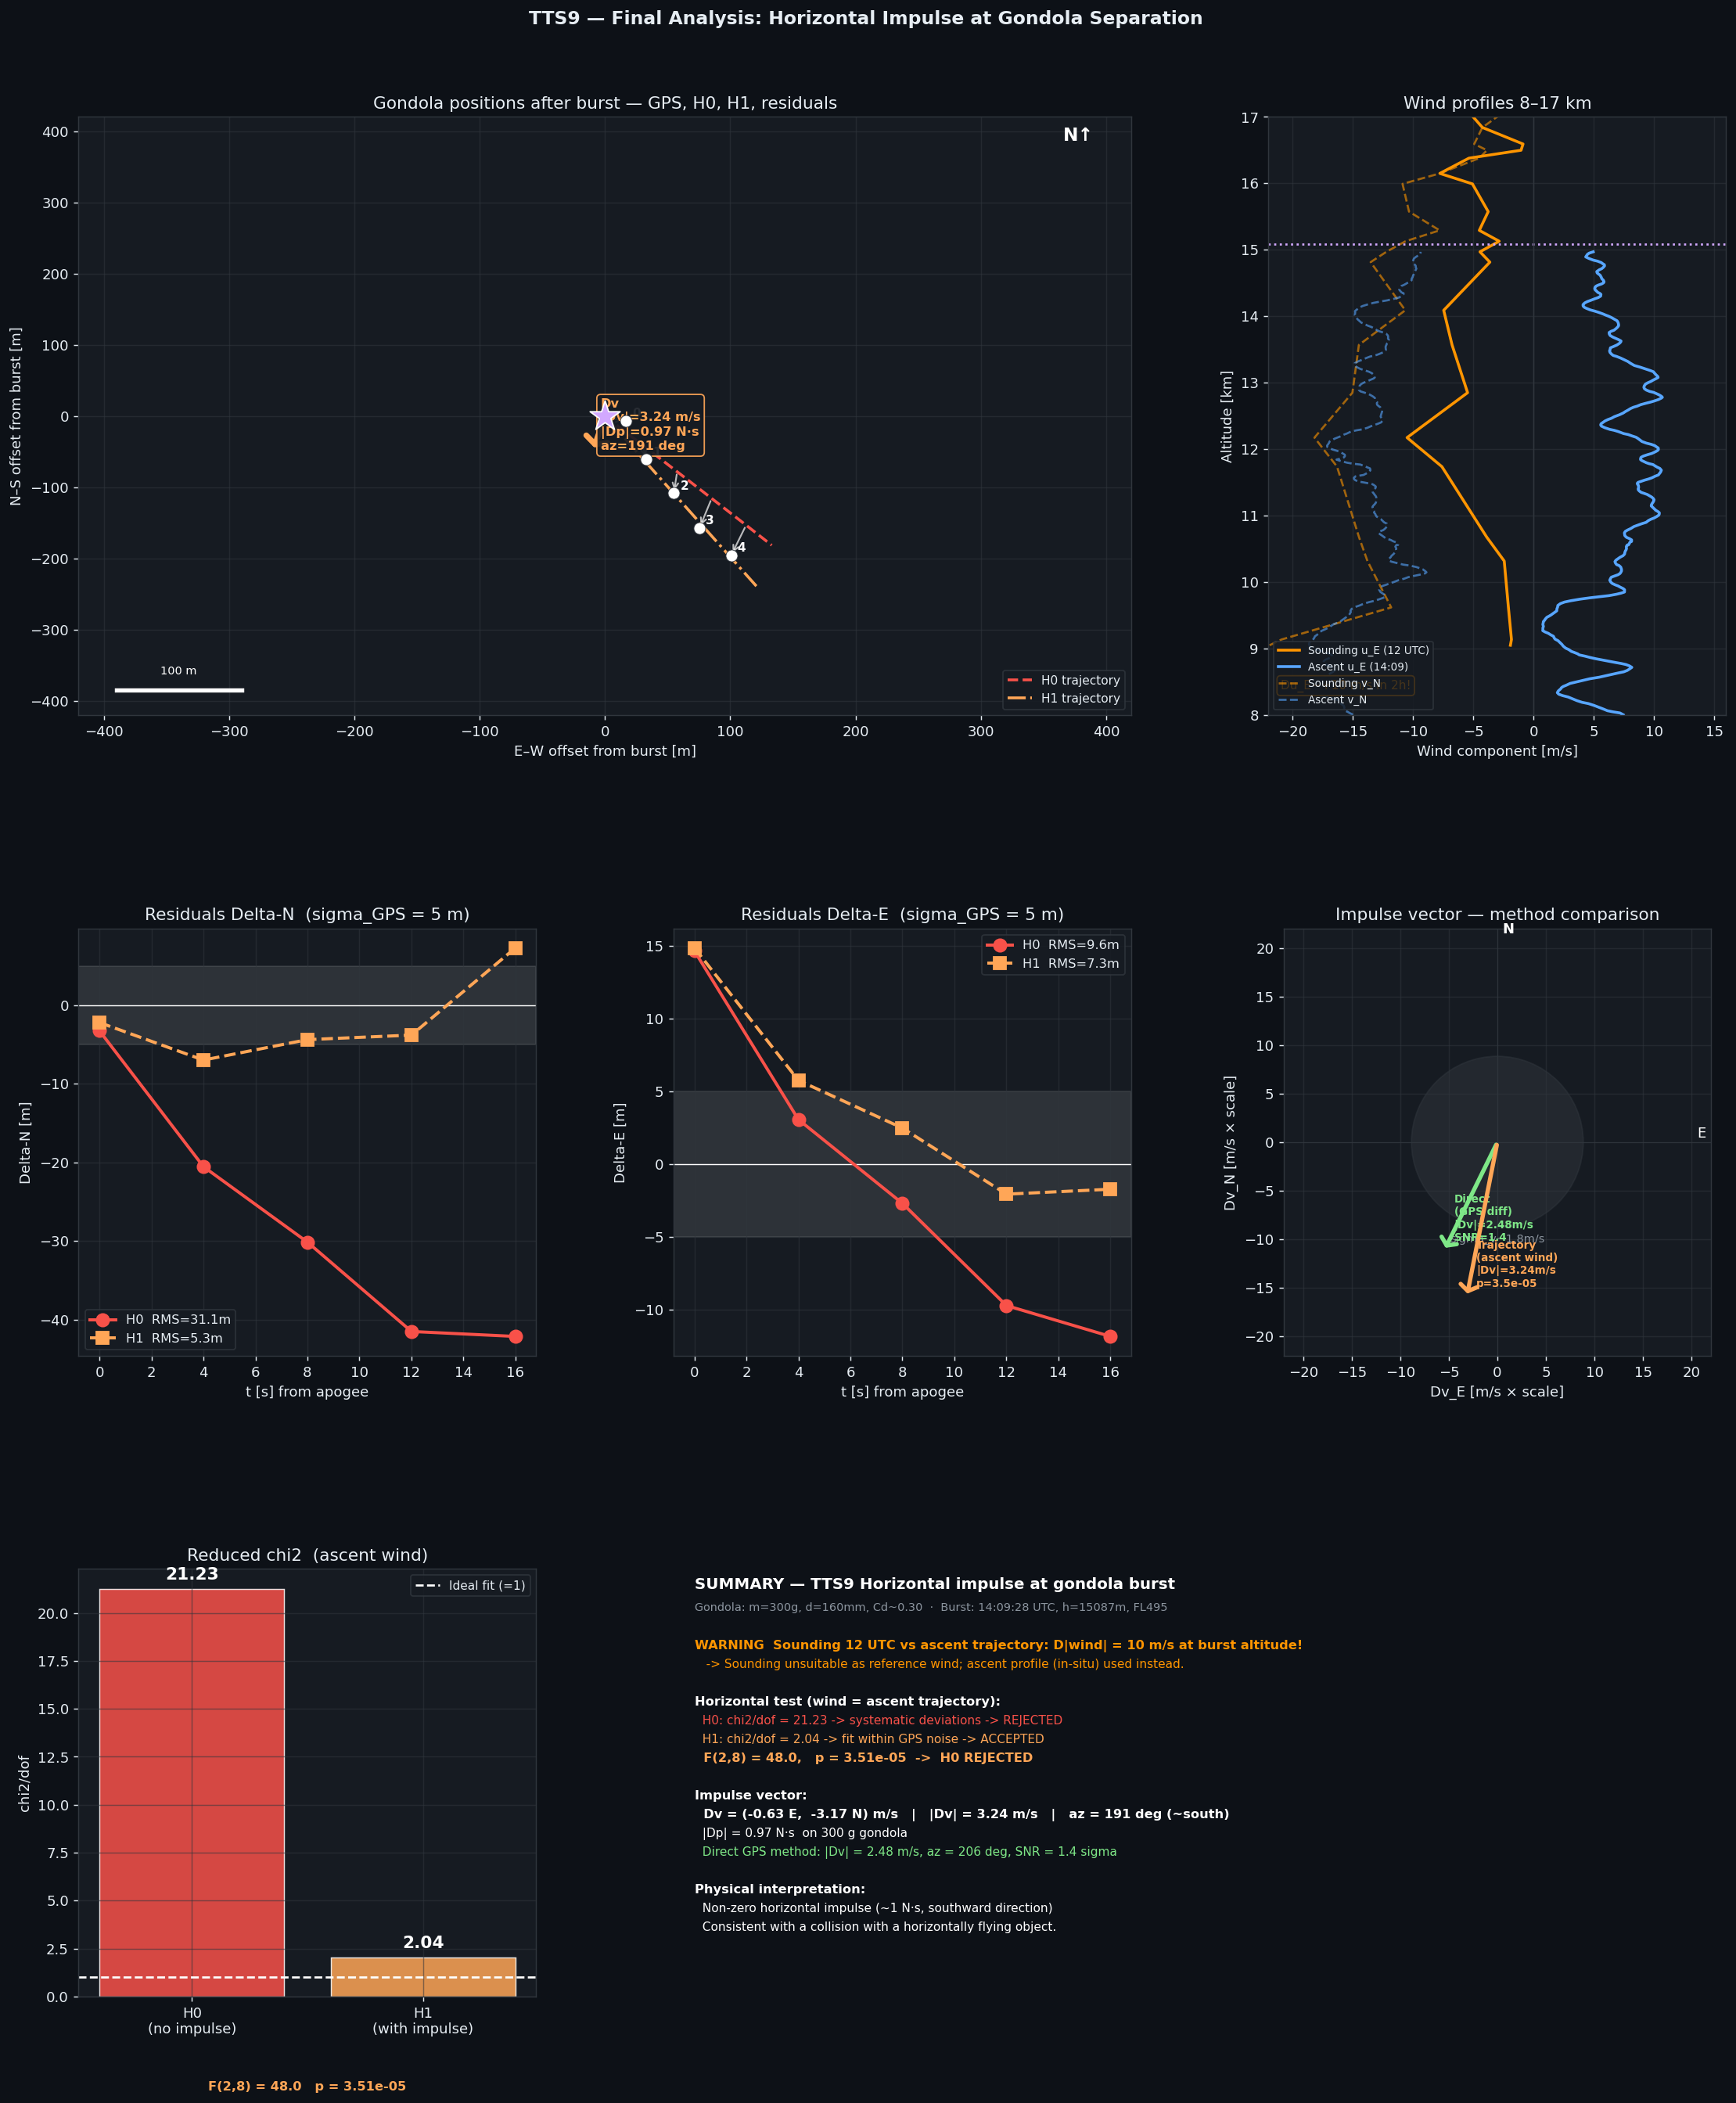


Figure saved: TTS9_final_analysis.png


In [13]:
fig = plt.figure(figsize=(18, 21))
gs  = gridspec.GridSpec(3, 3, fig, left=0.07, right=0.97, top=0.93, bottom=0.05,
                        hspace=0.44, wspace=0.30, height_ratios=[1.4, 1.0, 1.0])
ax_map  = fig.add_subplot(gs[0, :2])
ax_wind = fig.add_subplot(gs[0,  2])
ax_rN   = fig.add_subplot(gs[1,  0])
ax_rE   = fig.add_subplot(gs[1,  1])
ax_vec  = fig.add_subplot(gs[1,  2])
ax_chi  = fig.add_subplot(gs[2,  0])
ax_sum  = fig.add_subplot(gs[2, 1:])

# ── MAP ───────────────────────────────────────────────────
def tm(lat, lon):
    return (np.atleast_1d(lon) - LON_SEP)*M_PER_DEG_LON, \
           (np.atleast_1d(lat) - LAT_SEP)*M_PER_DEG_LAT

msk_sim = (ts1 >= td_h[0]-0.5) & (ts1 <= td_h[-1]+3)
ax_map.plot(*tm(la0[msk_sim], lo0[msk_sim]), color=COLORS['h0'], lw=2, ls='--', label='H0 trajectory')
ax_map.plot(*tm(la1[msk_sim], lo1[msk_sim]), color=COLORS['h1'], lw=2, ls='-.', label='H1 trajectory')
for i in range(N_HORIZ):
    xm, ym = tm(lm_h[i], om_h[i]); xm=float(xm); ym=float(ym)
    x0, y0 = tm(la0_eval[i], lo0_eval[i]); x0=float(x0); y0=float(y0)
    ax_map.scatter(xm, ym, color='white', s=70, zorder=7, edgecolors='#30363d', lw=0.5)
    ax_map.annotate('', xy=(xm,ym), xytext=(x0,y0),
                    arrowprops=dict(arrowstyle='->', color='white', lw=1.2, alpha=0.7))
    ax_map.text(xm+5, ym+5, str(i), color='white', fontsize=8.5, fontweight='bold')
ax_map.scatter([0],[0], s=500, color=COLORS['burst'], marker='*', zorder=10, edgecolors='white')
sc = 15
ax_map.annotate('', xy=(DV_E*sc, DV_N*sc), xytext=(0,0),
                arrowprops=dict(arrowstyle='->,head_width=0.8', color=COLORS['h1'], lw=4))
ax_map.text(DV_E*sc+6, DV_N*sc,
            f'Dv\n|Dv|={DV_MAG:.2f} m/s\n|Dp|={DP_MAG:.2f} N·s\naz={AZ:.0f} deg',
            color=COLORS['h1'], fontsize=9, fontweight='bold',
            bbox=dict(facecolor='#161b22', edgecolor=COLORS['h1'], alpha=0.92, boxstyle='round,pad=0.3'))
lim=420
ax_map.set_xlim(-lim,lim); ax_map.set_ylim(-lim,lim)
ax_map.plot([-lim+30,-lim+130],[-lim+35,-lim+35], color='white', lw=3)
ax_map.text(-lim+80,-lim+58,'100 m',ha='center',color='white',fontsize=8)
ax_map.text(lim*0.87,lim*0.92,'N↑',color='white',fontsize=13,fontweight='bold')
ax_map.set_xlabel('E–W offset from burst [m]'); ax_map.set_ylabel('N–S offset from burst [m]')
ax_map.set_title('Gondola positions after burst — GPS, H0, H1, residuals')
ax_map.legend(fontsize=8.5, loc='lower right')

# ── WIND ─────────────────────────────────────────────────
hband = SND['h'].between(8000,18000)
hasc  = (h_asc_wind >= 8000) & (h_asc_wind <= 16500)
ax_wind.plot(SND.loc[hband,'u_E'], SND.loc[hband,'h']/1000,
             color=COLORS['snd'], lw=2, label='Sounding u_E (12 UTC)')
ax_wind.plot(u_asc_wind[hasc], h_asc_wind[hasc]/1000,
             color=COLORS['asc'], lw=2, label='Ascent u_E (14:09)')
ax_wind.plot(SND.loc[hband,'v_N'], SND.loc[hband,'h']/1000,
             color=COLORS['snd'], lw=1.5, ls='--', alpha=0.6, label='Sounding v_N')
ax_wind.plot(v_asc_wind[hasc], h_asc_wind[hasc]/1000,
             color=COLORS['asc'], lw=1.5, ls='--', alpha=0.6, label='Ascent v_N')
ax_wind.axhline(H_SEP/1000, color=COLORS['burst'], lw=1.5, ls=':')
ax_wind.axvline(0, color='#30363d', lw=0.8)
ax_wind.set_xlabel('Wind component [m/s]'); ax_wind.set_ylabel('Altitude [km]')
ax_wind.set_title('Wind profiles 8–17 km')
ax_wind.set_xlim(-22,16); ax_wind.set_ylim(8,17)
ax_wind.legend(fontsize=7.5, loc='lower left', ncol=1)
ax_wind.text(-21,8.4,f'Du_E~+{delta_u:.0f} m/s in 2h!',color=COLORS['snd'],fontsize=8.5,
             bbox=dict(facecolor='#161b22',edgecolor=COLORS['snd'],alpha=0.9,boxstyle='round,pad=0.3'))

# ── RESIDUALS ─────────────────────────────────────────────
for ax2, r0, r1, lbl in [(ax_rN, res_lat0, res_lat1, 'N'),
                          (ax_rE, res_lon0, res_lon1, 'E')]:
    ax2.axhline(0, color='white', lw=0.8)
    ax2.axhspan(-SIGMA_HOR, SIGMA_HOR, alpha=0.10, color='white')
    ax2.plot(td_h, r0, 'o-', color=COLORS['h0'], ms=9, lw=2.2,
             label=f'H0  RMS={np.sqrt(np.mean(r0**2)):.1f}m')
    ax2.plot(td_h, r1, 's--', color=COLORS['h1'], ms=9, lw=2.2,
             label=f'H1  RMS={np.sqrt(np.mean(r1**2)):.1f}m')
    ax2.set_xlabel('t [s] from apogee'); ax2.set_ylabel(f'Delta-{lbl} [m]')
    ax2.set_title(f'Residuals Delta-{lbl}  (sigma_GPS = {SIGMA_HOR:.0f} m)')
    ax2.legend(fontsize=9)

# ── IMPULSE VECTOR ────────────────────────────────────────
ax_vec.set_aspect('equal')
sc2 = 5
circ = Circle((0,0), sigma_v*sc2, fill=True, color='#30363d', alpha=0.5, zorder=1)
ax_vec.add_patch(circ)
ax_vec.text(0,-sigma_v*sc2-1.5,f'sigma_v~{sigma_v:.1f}m/s',ha='center',color='#8b949e',fontsize=8)
mvec = [('Direct\n(GPS diff)', dv_E_dir, dv_N_dir, COLORS['direct'], f'SNR={SNR:.1f}'),
        ('Trajectory\n(ascent wind)', DV_E, DV_N, COLORS['h1'], f'p={p_val_h:.1e}')]
for lbl,dve,dvn,col,stat in mvec:
    ax_vec.annotate('',xy=(dve*sc2,dvn*sc2),xytext=(0,0),
                    arrowprops=dict(arrowstyle='->,head_width=0.6',color=col,lw=3))
    ax_vec.text(dve*sc2+1,dvn*sc2+1,
                f'{lbl}\n|Dv|={np.sqrt(dve**2+dvn**2):.2f}m/s\n{stat}',
                color=col,fontsize=7.5,fontweight='bold')
lv=22; ax_vec.set_xlim(-lv,lv); ax_vec.set_ylim(-lv,lv)
ax_vec.plot([-lv,lv],[0,0],color='#30363d',lw=0.5); ax_vec.plot([0,0],[-lv,lv],color='#30363d',lw=0.5)
ax_vec.text(lv-0.5,0.5,'E',color='white',fontsize=10,ha='right')
ax_vec.text(0.5,lv-0.5,'N',color='white',fontsize=10,fontweight='bold')
ax_vec.set_xlabel('Dv_E [m/s × scale]'); ax_vec.set_ylabel('Dv_N [m/s × scale]')
ax_vec.set_title('Impulse vector — method comparison')

# ── CHI² ─────────────────────────────────────────────────
v0 = chi2_0h/N_obs; v1 = chi2_1h/dof1h
bars = ax_chi.bar(['H0\n(no impulse)','H1\n(with impulse)'], [v0,v1],
                  color=[COLORS['h0'],COLORS['h1']], alpha=0.85, edgecolor='white', lw=0.8)
ax_chi.axhline(1, color='white', lw=1.5, ls='--', label='Ideal fit (=1)')
for bar,v in zip(bars,[v0,v1]):
    ax_chi.text(bar.get_x()+bar.get_width()/2, v+0.5,
                f'{v:.2f}', ha='center', color='white', fontsize=12, fontweight='bold')
ax_chi.set_ylabel('chi2/dof')
ax_chi.set_title('Reduced chi2  (ascent wind)')
ax_chi.legend(fontsize=8.5)
ax_chi.text(0.5,-0.22,f'F(2,{dof1h}) = {F_h:.1f}   p = {p_val_h:.2e}',
            transform=ax_chi.transAxes, ha='center', color=COLORS['h1'], fontsize=9, fontweight='bold')

# ── SUMMARY TEXT ──────────────────────────────────────────
ax_sum.set_facecolor('#161b22'); ax_sum.axis('off')
for s in ax_sum.spines.values(): s.set_edgecolor('#30363d')
rows = [
    ('SUMMARY — TTS9 Horizontal impulse at gondola burst', 'white', 11, True),
    (f'Gondola: m={M_GON*1000:.0f}g, d={D_SPH*1000:.0f}mm, Cd~{K_VERT*2*M_GON/A_SPH:.2f}  ·  Burst: {hh:02d}:{mm:02d}:{ss:02d} UTC, h={H_SEP:.0f}m, FL{int(round(geom_to_pa_ft(H_SEP)/100))}', '#8b949e', 8, False),
    ('', 'white', 5, False),
    (f'WARNING  Sounding 12 UTC vs ascent trajectory: D|wind| = {delta_wind:.0f} m/s at burst altitude!', COLORS['snd'], 9, True),
    ('   -> Sounding unsuitable as reference wind; ascent profile (in-situ) used instead.', COLORS['snd'], 8.5, False),
    ('', 'white', 5, False),
    ('Horizontal test (wind = ascent trajectory):', 'white', 9, True),
    (f'  H0: chi2/dof = {v0:.2f} -> systematic deviations -> REJECTED', COLORS['h0'], 8.5, False),
    (f'  H1: chi2/dof = {v1:.2f} -> fit within GPS noise -> ACCEPTED', COLORS['h1'], 8.5, False),
    (f'  F(2,{dof1h}) = {F_h:.1f},   p = {p_val_h:.2e}  ->  H0 REJECTED', COLORS['h1'], 9, True),
    ('', 'white', 5, False),
    ('Impulse vector:', 'white', 9, True),
    (f'  Dv = ({DV_E:+.2f} E,  {DV_N:+.2f} N) m/s   |   |Dv| = {DV_MAG:.2f} m/s   |   az = {AZ:.0f} deg (~south)', 'white', 9, True),
    (f'  |Dp| = {DP_MAG:.2f} N·s  on {M_GON*1000:.0f} g gondola', 'white', 8.5, False),
    (f'  Direct GPS method: |Dv| = {dv_dir:.2f} m/s, az = {az_dir:.0f} deg, SNR = {SNR:.1f} sigma', COLORS['direct'], 8.5, False),
    ('', 'white', 5, False),
    ('Physical interpretation:', 'white', 9, True),
    (f'  Non-zero horizontal impulse (~1 N·s, southward direction)', 'white', 8.5, False),
    ('  Consistent with a collision with a horizontally flying object.', 'white', 8.5, False),
]
y = 0.98
for txt, col, fs, bold in rows:
    ax_sum.text(0.02, y, txt, transform=ax_sum.transAxes,
                color=col, fontsize=fs, fontweight='bold' if bold else 'normal', va='top')
    y -= 0.057 if fs >= 9.5 else 0.044

fig.suptitle('TTS9 — Final Analysis: Horizontal Impulse at Gondola Separation', fontsize=13, fontweight='bold')
plt.savefig('TTS9_final_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print("\nFigure saved: TTS9_final_analysis.png")


## 10  Results summary

In [14]:
results_df = pd.DataFrame({
    'Parameter': [
        'Burst location — latitude', 'Burst location — longitude', 'Burst altitude',
        'Pressure altitude', 'Burst time',
        '──────────────', '',
        'k_vert (Cd·A/2m)', 'Cd (fitted)',
        '──────────────', '',
        '|Dv_hor| (trajectory)', 'Impulse azimuth', '|Dp_hor|',
        'Horizontal F-test p', 'Horizontal conclusion',
        '──────────────', '',
        '|Dv_hor| (direct method)', 'Azimuth (direct)', 'SNR',
    ],
    'Value': [
        f'{LAT_SEP:.6f} N', f'{LON_SEP:.6f} E', f'{H_SEP:.1f} m',
        f'FL{int(round(geom_to_pa_ft(H_SEP)/100))} ({isa_pressure_hPa(H_SEP):.1f} hPa)',
        f'{hh:02d}:{mm:02d}:{ss:02d} UTC',
        '', '',
        f'{K_VERT:.5f} m²/kg', f'{K_VERT*2*M_GON/A_SPH:.3f}',
        '', '',
        f'{DV_MAG:.3f} m/s', f'{AZ:.1f} deg from north (~south)',
        f'{DP_MAG:.3f} N·s',
        f'{p_val_h:.2e}', 'H0 REJECTED',
        '', '',
        f'{dv_dir:.3f} m/s', f'{az_dir:.1f} deg from north',
        f'{SNR:.2f} sigma',
    ]
})
print(results_df.to_string(index=False))


                 Parameter                         Value
 Burst location — latitude                   49.700500 N
Burst location — longitude                   14.594150 E
            Burst altitude                     15086.7 m
         Pressure altitude             FL495 (118.8 hPa)
                Burst time                  14:09:28 UTC
            ──────────────                              
                                                        
          k_vert (Cd·A/2m)                 0.01022 m²/kg
               Cd (fitted)                         0.305
            ──────────────                              
                                                        
     |Dv_hor| (trajectory)                     3.236 m/s
           Impulse azimuth 191.2 deg from north (~south)
                  |Dp_hor|                     0.971 N·s
       Horizontal F-test p                      3.51e-05
     Horizontal conclusion                   H0 REJECTED
            ──────────────     